# NB07 — Biological Validation
**Project:** NAFLD Stage-Specific Biomarker Discovery (Single-Dataset Pipeline)  
**Dataset:** GSE135251

---

**Purpose:** Ground the machine learning findings in known biological truth. We take the top stage-specific SHAP biomarkers discovered in NB06 and perform Gene Ontology (GO) and KEGG pathway enrichment analysis for each NAFLD stage independently. 

**Outputs:**
- `results/tables/go_enrichment_per_class.csv`
- `results/tables/kegg_enrichment_per_class.csv`
- `results/figures/go_enrichment_dotplots.png`


## 1. Install Dependencies

In [1]:
# ── DEPENDENCIES ──────────────────────────────────────────────────
import subprocess, sys

packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "gseapy",
    "requests"
]

for pkg in packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg, "--quiet"]
    )

print("All dependencies installed.")


All dependencies installed.


## 2. Configuration & Imports

In [2]:
import os, pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import requests
import warnings
warnings.filterwarnings("ignore")

# ── CONFIGURATION ─────────────────────────────────────────────────
# Paths
PROJECT_ROOT = pathlib.Path("..").resolve()
RESULTS_TAB  = PROJECT_ROOT / "results" / "tables"
RESULTS_FIG  = PROJECT_ROOT / "results" / "figures"

CLASS_NAMES = ["Healthy", "Steatosis", "NASH", "Adv. Fibrosis"]


## 3. Load Stage-Specific Biomarkers

In [3]:
shap_path = RESULTS_TAB / "top_shap_genes_per_class.csv"
shap_df = pd.read_csv(shap_path)

# Extract top 30 genes per class for enrichment
top_genes_dict = {}
for k, class_name in enumerate(CLASS_NAMES):
    # Get top 30 from XGBoost
    xgb_genes = shap_df[(shap_df['class_id'] == k) & (shap_df['model'] == 'xgboost')]['gene'].head(30).tolist()
    class_genes = list(set(xgb_genes))
    top_genes_dict[k] = class_genes
    print(f"{class_name}: {len(class_genes)} unique genes extracted.")


Healthy: 30 unique genes extracted.
Steatosis: 30 unique genes extracted.
NASH: 30 unique genes extracted.
Adv. Fibrosis: 30 unique genes extracted.


## 4. Run GO & KEGG Enrichment Analysis via Enrichr

In [4]:
go_db = 'GO_Biological_Process_2023'
kegg_db = 'KEGG_2021_Human'

all_go_results = []
all_kegg_results = []

for k, class_name in enumerate(CLASS_NAMES):
    genes = top_genes_dict[k]
    if len(genes) < 5:
        continue
        
    print(f"Running enrichment for {class_name}...")
    
    # GO BP
    try:
        enr_go = gp.enrichr(gene_list=genes, gene_sets=go_db, organism='human', outdir=None)
        if not enr_go.results.empty:
            df = enr_go.results
            df['class_id'] = k
            df['class_name'] = class_name
            all_go_results.append(df[df['Adjusted P-value'] < 0.05])
    except Exception as e:
        print(f"  GO enrichment failed for {class_name}: {e}")
        
    # KEGG
    try:
        enr_kegg = gp.enrichr(gene_list=genes, gene_sets=kegg_db, organism='human', outdir=None)
        if not enr_kegg.results.empty:
            df = enr_kegg.results
            df['class_id'] = k
            df['class_name'] = class_name
            all_kegg_results.append(df[df['Adjusted P-value'] < 0.05])
    except Exception as e:
        print(f"  KEGG enrichment failed for {class_name}: {e}")

# Compile
if all_go_results:
    go_df = pd.concat(all_go_results, ignore_index=True)
    go_csv = RESULTS_TAB / "go_enrichment_per_class.csv"
    go_df.to_csv(go_csv, index=False)
    print(f"\nSaved GO results: {go_csv}")
else:
    go_df = pd.DataFrame()

if all_kegg_results:
    kegg_df = pd.concat(all_kegg_results, ignore_index=True)
    kegg_csv = RESULTS_TAB / "kegg_enrichment_per_class.csv"
    kegg_df.to_csv(kegg_csv, index=False)
    print(f"Saved KEGG results: {kegg_csv}")
else:
    kegg_df = pd.DataFrame()


Running enrichment for Healthy...
Running enrichment for Steatosis...
Running enrichment for NASH...
Running enrichment for Adv. Fibrosis...

Saved GO results: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\tables\go_enrichment_per_class.csv
Saved KEGG results: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\tables\kegg_enrichment_per_class.csv


## 5. Visualize GO Enrichment

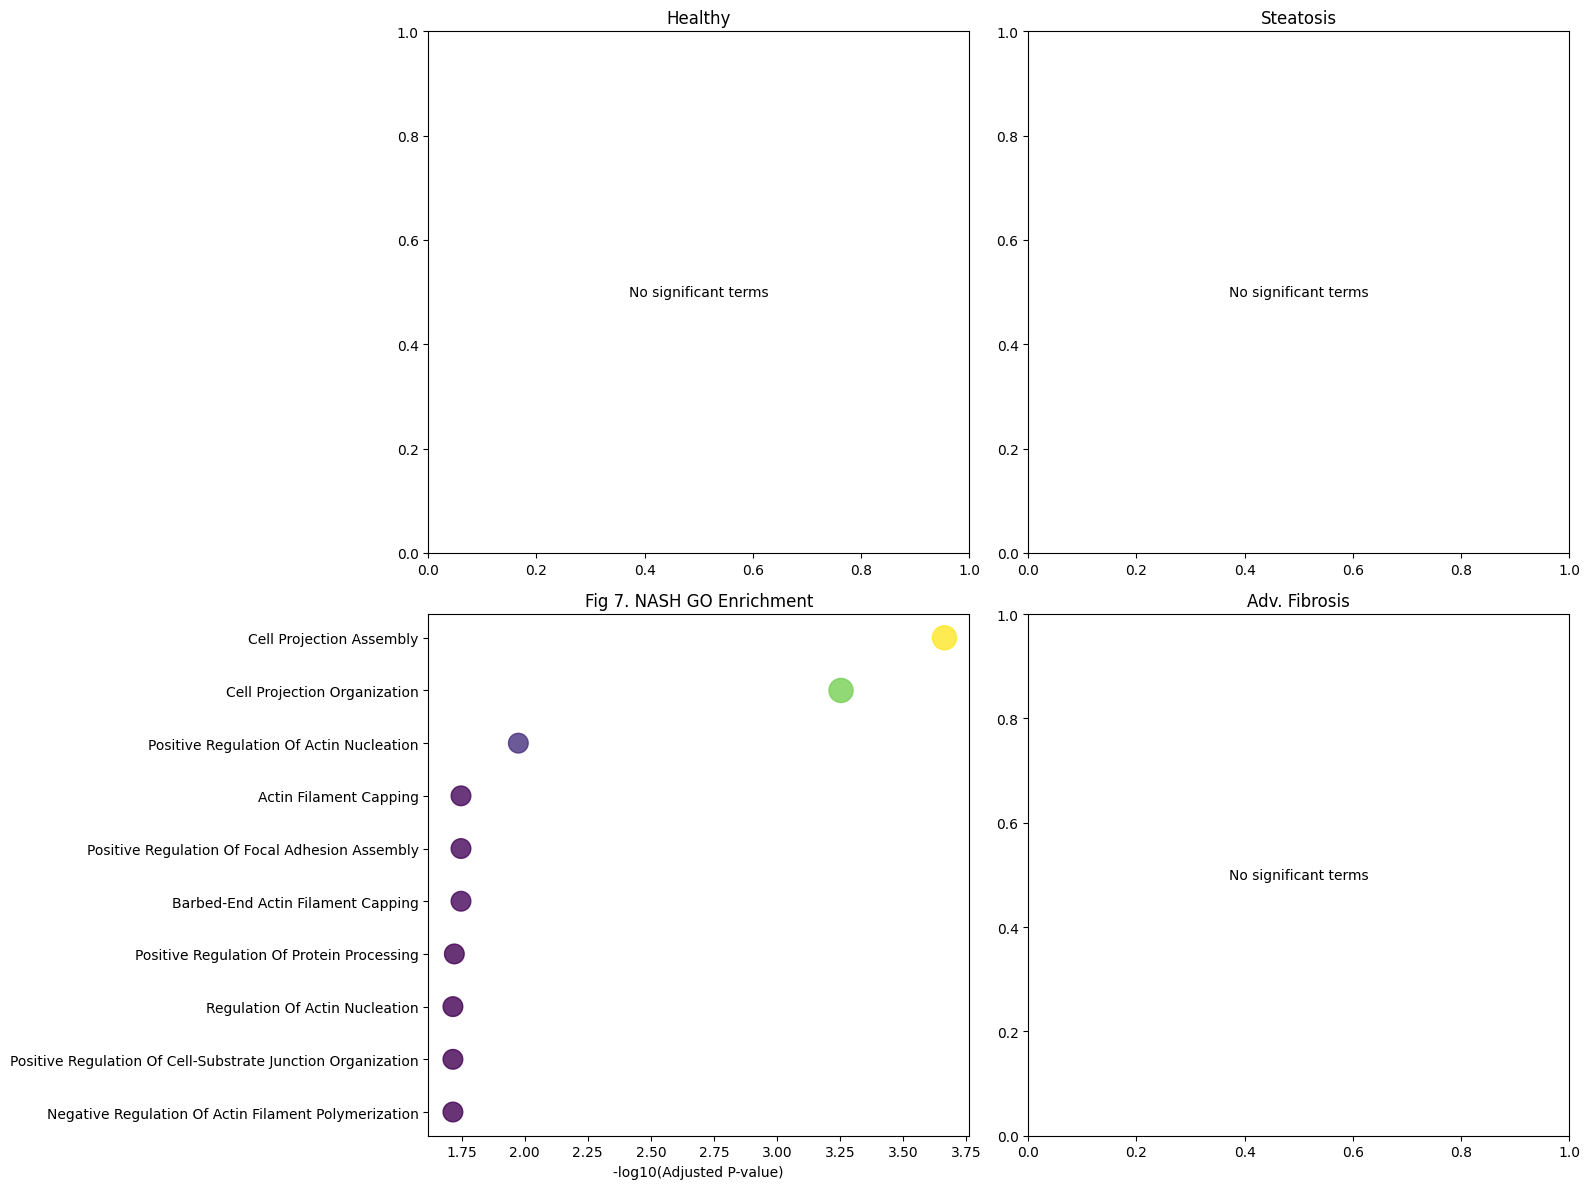

In [5]:
if not go_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for k, class_name in enumerate(CLASS_NAMES):
        ax = axes[k]
        class_df = go_df[go_df['class_id'] == k].sort_values('Adjusted P-value').head(10)
        
        if class_df.empty:
            ax.text(0.5, 0.5, "No significant terms", ha='center', va='center')
            ax.set_title(class_name)
            continue
            
        # Extract overlap count (e.g., "5/100" -> 5)
        class_df['Count'] = class_df['Overlap'].str.split('/').str[0].astype(int)
        
        # Log P value for color
        class_df['-log10(p_adj)'] = -np.log10(class_df['Adjusted P-value'])
        
        # Sort for plot
        class_df = class_df.sort_values('-log10(p_adj)', ascending=True)
        
        scatter = ax.scatter(class_df['-log10(p_adj)'], class_df['Term'], 
                             s=class_df['Count']*100, c=class_df['-log10(p_adj)'], 
                             cmap='viridis', alpha=0.8)
        
        ax.set_title(f"Fig 7. {class_name} GO Enrichment", fontsize=12)
        ax.set_xlabel("-log10(Adjusted P-value)")
        
        # Clean Y-axis terms
        clean_terms = [t.split(" (GO:")[0] for t in class_df['Term']]
        ax.set_yticklabels(clean_terms)
        
    plt.tight_layout()
    fig_path = RESULTS_FIG / "fig7_go_enrichment_dotplots.png"
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No significant GO terms found across all classes.")
